# Horizon Comparison

This notebook evaluates baseline models across all five FI-2010 forecast horizons. The goal is to understand how prediction difficulty changes as the target horizon changes, using the same train/test split and evaluation metrics for each horizon.

In [5]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import importlib
import lob_forecasting.data as data
importlib.reload(data)
from lob_forecasting.data import load_fi2010_split

In [6]:
X_train, y_train_all, X_test, y_test_all = load_fi2010_split(
    project_root=PROJECT_ROOT,
    market="NoAuction",
    normalization="Zscore",
    cf=1,
    verbose=True,
)

X_train: (39512, 144)
y_train_all: (39512, 5)
X_test: (38397, 144)
y_test_all: (38397, 5)


In [7]:
def class_distribution_table(y_all, split_name):
    rows = []

    for horizon in range(y_all.shape[1]):
        y_horizon = y_all[:, horizon].astype(int)
        values, counts = np.unique(y_horizon, return_counts=True)
        total = len(y_horizon)

        for value, count in zip(values, counts):
            rows.append({
                "split": split_name,
                "horizon": horizon,
                "class": value,
                "count": count,
                "percentage": count / total
            })

    return pd.DataFrame(rows)

In [17]:
def make_baseline():
    return DummyClassifier(strategy="most_frequent")

def make_logreg():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )

def make_hgb():
    return HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42,
    )

In [9]:
def evaluate_model_predictions(y_true, y_pred, model_name, horizon):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[1, 2, 3],
        zero_division=0
    )

    return {
        "model": model_name,
        "horizon": horizon,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "precision_up": precision[0],
        "recall_up": recall[0],
        "f1_up": f1[0],
        "support_up": support[0],
        "precision_flat": precision[1],
        "recall_flat": recall[1],
        "f1_flat": f1[1],
        "support_flat": support[1],
        "precision_down": precision[2],
        "recall_down": recall[2],
        "f1_down": f1[2],
        "support_down": support[2],
    }

In [18]:
model_builders = {
    "Majority baseline": make_baseline,
    "Logistic regression": make_logreg,
    "HistGradientBoosting": make_hgb,
}

results = []

for horizon in range(y_train_all.shape[1]):
    y_train = y_train_all[:, horizon].astype(int)
    y_test = y_test_all[:, horizon].astype(int)

    for model_name, build_model in model_builders.items():
        model = build_model()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        
        row = evaluate_model_predictions(
            y_true=y_test,
            y_pred=y_pred,
            model_name=model_name,
            horizon=horizon
        )

        results.append(row)




In [19]:
results_df = pd.DataFrame(results)
results_df

,model,horizon,accuracy,macro_f1,precision_up,recall_up,f1_up,support_up,precision_flat,recall_flat,f1_flat,support_flat,precision_down,recall_down,f1_down,support_down
0,Majority baseline,0,0.591166,0.247687,0.000000,0.000000,0.000000,8007,0.591166,1.000000,0.743060,22699,0.000000,0.000000,0.000000,7691
1,Logistic regression,0,0.414277,0.396816,0.302480,0.391408,0.341246,8007,0.721879,0.375743,0.494234,22699,0.261636,0.551814,0.354968,7691
2,HistGradientBoosting,0,0.625674,0.491166,0.453056,0.293493,0.356223,8007,0.694398,0.854575,0.766205,22699,0.431469,0.295930,0.351072,7691
3,Majority baseline,1,0.481444,0.216655,0.000000,0.000000,0.000000,10200,0.481444,1.000000,0.649966,18486,0.000000,0.000000,0.000000,9711
4,Logistic regression,1,0.437248,0.430284,0.395057,0.394902,0.394979,10200,0.614552,0.414422,0.495025,18486,0.324118,0.525178,0.400849,9711
5,HistGradientBoosting,1,0.666745,0.617036,0.639749,0.480000,0.548479,10200,0.686148,0.878340,0.770439,18486,0.631073,0.460097,0.532190,9711
6,Majority baseline,2,0.405344,0.192287,0.000000,0.000000,0.000000,11789,0.405344,1.000000,0.576861,15564,0.000000,0.000000,0.000000,11044
7,Logistic regression,2,0.424512,0.423697,0.427183,0.395114,0.410523,11789,0.525930,0.359676,0.427198,15564,0.358716,0.547265,0.433370,11044
8,HistGradientBoosting,2,0.582806,0.572985,0.563568,0.520400,0.541125,11789,0.634519,0.669172,0.651385,15564,0.525187,0.527707,0.526444,11044
9,Majority baseline,3,0.305987,0.156197,0.000000,0.000000,0.000000,13764,0.305987,1.000000,0.468592,11749,0.000000,0.000000,0.000000,12884


In [13]:
results_df = results_df.sort_values(
    ["horizon", "macro_f1"],
    ascending=[True, False]
)

results_df

,model,horizon,accuracy,macro_f1,precision_up,recall_up,f1_up,support_up,precision_flat,recall_flat,f1_flat,support_flat,precision_down,recall_down,f1_down,support_down
2,HistGradientBoosting,0,0.625674,0.491166,0.453056,0.293493,0.356223,8007,0.694398,0.854575,0.766205,22699,0.431469,0.295930,0.351072,7691
1,Logistic regression,0,0.414277,0.396816,0.302480,0.391408,0.341246,8007,0.721879,0.375743,0.494234,22699,0.261636,0.551814,0.354968,7691
0,Majority baseline,0,0.591166,0.247687,0.000000,0.000000,0.000000,8007,0.591166,1.000000,0.743060,22699,0.000000,0.000000,0.000000,7691
5,HistGradientBoosting,1,0.666745,0.617036,0.639749,0.480000,0.548479,10200,0.686148,0.878340,0.770439,18486,0.631073,0.460097,0.532190,9711
4,Logistic regression,1,0.437248,0.430284,0.395057,0.394902,0.394979,10200,0.614552,0.414422,0.495025,18486,0.324118,0.525178,0.400849,9711
3,Majority baseline,1,0.481444,0.216655,0.000000,0.000000,0.000000,10200,0.481444,1.000000,0.649966,18486,0.000000,0.000000,0.000000,9711
8,HistGradientBoosting,2,0.582806,0.572985,0.563568,0.520400,0.541125,11789,0.634519,0.669172,0.651385,15564,0.525187,0.527707,0.526444,11044
7,Logistic regression,2,0.424512,0.423697,0.427183,0.395114,0.410523,11789,0.525930,0.359676,0.427198,15564,0.358716,0.547265,0.433370,11044
6,Majority baseline,2,0.405344,0.192287,0.000000,0.000000,0.000000,11789,0.405344,1.000000,0.576861,15564,0.000000,0.000000,0.000000,11044
11,HistGradientBoosting,3,0.522046,0.508099,0.526199,0.601206,0.561207,13764,0.610398,0.315772,0.416223,11749,0.485747,0.625582,0.546867,12884


In [20]:
summary_cols = [
    "horizon",
    "model",
    "accuracy",
    "macro_f1",
    "f1_up",
    "f1_flat",
    "f1_down",
]

summary_df = results_df[summary_cols]
summary_df

,horizon,model,accuracy,macro_f1,f1_up,f1_flat,f1_down
0,0,Majority baseline,0.591166,0.247687,0.000000,0.743060,0.000000
1,0,Logistic regression,0.414277,0.396816,0.341246,0.494234,0.354968
2,0,HistGradientBoosting,0.625674,0.491166,0.356223,0.766205,0.351072
3,1,Majority baseline,0.481444,0.216655,0.000000,0.649966,0.000000
4,1,Logistic regression,0.437248,0.430284,0.394979,0.495025,0.400849
5,1,HistGradientBoosting,0.666745,0.617036,0.548479,0.770439,0.532190
6,2,Majority baseline,0.405344,0.192287,0.000000,0.576861,0.000000
7,2,Logistic regression,0.424512,0.423697,0.410523,0.427198,0.433370
8,2,HistGradientBoosting,0.582806,0.572985,0.541125,0.651385,0.526444
9,3,Majority baseline,0.305987,0.156197,0.000000,0.468592,0.000000


In [21]:
RESULTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_DIR.mkdir(exist_ok=True)

output_path = RESULTS_DIR / "horizon_results_cf1.csv"
results_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /Users/sohamaggarwal/Desktop/limit-order-book-forecasting/experiments/horizon_results_cf1.csv


## Observations

HistGradientBoosting outperforms the majority and logistic baselines on horizons 0 through 3 by macro F1, suggesting that nonlinear feature interactions are useful for FI-2010 mid-price movement prediction.

Horizon 1 gives the strongest macro-F1 performance among the tested horizons, while horizon 4 becomes less stable. In particular, HistGradientBoosting has higher accuracy than logistic regression on horizon 4, but much lower flat-class F1.

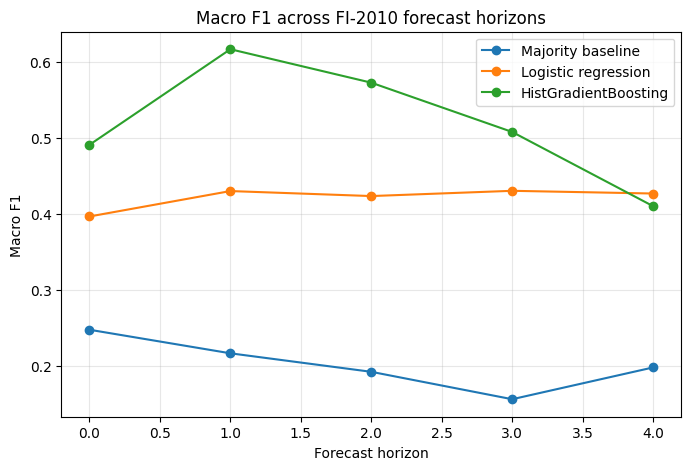

In [22]:
plt.figure(figsize=(8, 5))

for model_name in summary_df["model"].unique():
    model_results = summary_df[summary_df["model"] == model_name].sort_values("horizon")
    plt.plot(
        model_results["horizon"],
        model_results["macro_f1"],
        marker="o",
        label=model_name
    )

plt.xlabel("Forecast horizon")
plt.ylabel("Macro F1")
plt.title("Macro F1 across FI-2010 forecast horizons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()